# Adaptive NIDS → Reinforcement-Learning IPS: Full Codebase Lab

This notebook is the single entry point for the project. Each section explains **why the cell exists**, runs the real repository code, and interprets what the current output proves. It distinguishes saved historical model evidence, live tests, simulator evidence, dataset-backed observations, and cyber-range work that is still missing.

## 0 — Runtime controls

`RUN_HEAVY=False` keeps the notebook suitable for a quick demonstration. Set it to `True` for more DQN episodes, five seeds, and the full pytest suite. Training and evaluation seeds remain separate.

In [1]:
from pathlib import Path
import inspect, json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
if REPO.name == 'notebooks': REPO = REPO.parent
SRC = REPO / 'src'
if str(SRC) not in sys.path: sys.path.insert(0, str(SRC))
RUN_HEAVY = False
SEED = 42
OUTPUT = REPO / 'results' / 'notebook_ips_lab'
OUTPUT.mkdir(parents=True, exist_ok=True)
print({'repo': str(REPO), 'python': sys.version.split()[0], 'run_heavy': RUN_HEAVY, 'output': str(OUTPUT)})

{'repo': "/Users/hexenmeister/Library/Mobile Documents/com~apple~CloudDocs/Desktop/don't delete update/codes/network-intrusion-detection-ml", 'python': '3.14.6', 'run_heavy': False, 'output': "/Users/hexenmeister/Library/Mobile Documents/com~apple~CloudDocs/Desktop/don't delete update/codes/network-intrusion-detection-ml/results/notebook_ips_lab"}


## 1 — Dynamic project inventory

This calls the same reporting code as `src/project_benchmark.py`. It discovers dependencies, local datasets, implemented tracks, saved benchmarks, feature representations, and IPS baselines from the current checkout. Missing data remains visible rather than being silently replaced.

In [2]:
import project_benchmark as PB
report = PB.build_report(full=False, episodes=200 if RUN_HEAVY else 50, seed=SEED, output_dir=OUTPUT / 'benchmark')
display(pd.DataFrame(report['datasets']))
display(pd.DataFrame(report['features']))
display(pd.DataFrame(report['tracks']))
print('Artifact counts:', report['artifact_counts'])

,dataset,role,status,limitation
0,NSL-KDD,Controlled baseline for every new method.,missing,None for current NSL-KDD baseline; temporal cl...
1,CICIoT2023 dev parquet,Fast modern IoT dev sample for quality checks ...,missing,Do not treat dev-sample results as full offici...
2,CICIoT2023 raw CSV,"Primary modern IoT supervised dataset: binary,...",blocked_missing_local_files,No full raw CSV modelling or quality claim unt...
3,TON_IoT,"Multimodal SOC/EDR-style track: network, IoT t...",blocked_missing_local_files,"No multimodal fusion, host telemetry, or TON_I..."
4,CSE-CIC-IDS2018,Enterprise-scale/day-based drift and chronolog...,blocked_missing_local_files,No enterprise/day-based drift result is valid ...
5,Common NetFlow schema,Cross-dataset generalization using shared NetF...,blocked_missing_local_files,No cross-dataset score is valid without a comm...


,representation,features,details
0,NSL-KDD raw flow,41,3 categorical + 38 numeric; difficulty excluded
1,Adaptive IPS state,7,"threat probability, anomaly, attack stage, com..."
2,CICIoT2023,46,published expected model features; local parqu...


,track,status,evidence
0,Leakage-safe preprocessing,PROVEN,src/preprocess.py + tests
1,Supervised reference models,PROVEN,results/reference_track.csv
2,RF/LightGBM official split,PROVEN,results/metrics.md
3,Weighted/unweighted MLP,PROVEN,results/stability.md
4,Threshold tuning,PROVEN,results/threshold_ablation.csv
5,Normal-only anomaly detection,PROVEN,results/anomaly_detection.csv
6,Semi-supervised learning,PROVEN,results/semi_supervised.csv
7,Online partial-fit proxy,PARTIAL,not chronological drift
8,CICIoT2023 supervised dev,PARTIAL,"random dev split, not full raw CSV"
9,Adaptive IPS environment,PROVEN,src/ips + safety tests


Artifact counts: {'figures': 43, 'csv_results': 26, 'markdown_results': 19, 'test_files': 21}


**How to read the output:** `PROVEN` means code plus saved evidence exists; `PARTIAL` means the method exists but the data/protocol cannot support the full claim; `BLOCKED` identifies the exact missing local data. Dataset availability and saved-result availability are different—committed metrics can exist while raw files are intentionally gitignored.

## 2 — Model training status and metric mathematics

This section shows where every model fitted, how it was selected, where it was evaluated, and the command that reproduces it. The formulas prevent incompatible leaderboards—for example, CICIoT random-dev macro-F1 must not be ranked directly against NSL-KDD official-shift macro-F1.

In [3]:
display(pd.DataFrame(report['model_training']).style.hide(axis='index'))
display(pd.DataFrame(report['metric_definitions']).style.hide(axis='index'))
display(pd.DataFrame(report['saved_benchmarks']).style.hide(axis='index'))

dataset_task,models,status,fit_selection,evaluation,run
NSL-KDD binary + 5-class,"Dummy, LogReg, RF, ExtraTrees, HistGB, LightGBM",TRAINED / SAVED,official train; class balancing; train-only validation/CV,official KDDTest+; macro-F1 + per-class recall,.venv/bin/python src/reference_track.py
NSL-KDD binary + 5-class,MLP unweighted + class-weighted,TRAINED / 5-SEED,official train; internal early-stopping validation,official KDDTest+; macro-F1 and rare-family recall,.venv/bin/python src/train_mlp.py
NSL-KDD anomaly,"IsolationForest, LOF, KMeans distance",TRAINED / SAVED,normal training rows only; train-normal quantile threshold,official KDDTest+ attack/family recall,.venv/bin/python src/anomaly_detection.py
CICIoT2023 dev binary + category,"Dummy, LogReg, RF, HistGB, LightGBM",TRAINED / DEV ONLY,stratified 200k train sample; random dev partition,full dev test partition; not raw/temporal evidence,.venv/bin/python src/ciciot2023_baselines.py
Adaptive IPS simulated episodes,"Allow-only, rule-based, aggressive",RUN LIVE IN THIS REPORT,no fitting; identical seeded scenarios,"containment, compromise, disruption, false prevention, return",.venv/bin/python src/project_benchmark.py
Adaptive IPS simulated episodes,Masked Double DQN,IMPLEMENTED / SMOKE WITH --full,training seed range; disjoint validation seed range,safety-first checkpoint ordering; simulator evidence only,.venv/bin/python src/project_benchmark.py --full


metric,calculation,use
accuracy,correct predictions / all predictions,secondary under imbalance
per-class recall,TP / (TP + FN) for that class,how many attacks of each family are caught
macro-F1,unweighted mean of each class F1; F1=2PR/(P+R),primary classifier comparison
weighted-F1,class F1 weighted by class support,overall volume-weighted quality
ROC-AUC,area under TPR versus FPR across thresholds,binary ranking; can flatter imbalance
PR-AUC,area under precision versus recall,preferred binary ranking under imbalance
containment rate,contained attack episodes / attack episodes,IPS prevention outcome
compromise rate,compromised attack episodes / attack episodes,lower is better; first checkpoint criterion
false prevention,disruptive actions in benign episodes / episodes,availability/safety cost
mean return,mean sum of transition rewards per episode,RL objective; never interpreted alone


track,artifact,status,best_macro_f1,best_method
NSL-KDD reference,results/reference_track.csv,missing,nan,nan
CICIoT2023 dev,results/ciciot2023_baselines.csv,available,0.856267,RandomForest (balanced)
Threshold ablation,results/threshold_ablation.csv,available,0.823031,HistGB_balanced
Anomaly detection,results/anomaly_detection.csv,available,0.841344,KMeans_distance
Semi-supervised,results/semi_supervised.csv,available,0.754244,labelled_only_logreg
Online proxy,results/online_learning.csv,available,0.764180,SGD_log_loss_balanced
Neural ablation,results/neural_ablation.csv,available,0.775930,nan


## 3 — Inspect the real implementation

Rather than duplicating source code in notebook cells, this dynamically displays the current implementations. Changes to the Python modules therefore appear here automatically.

In [4]:
from IPython.display import Code, display
from ips.environment import AdaptiveIpsEnv
from ips.actions import valid_action_mask
from ips.train_dqn import optimize_batch
from ips.dataset import build_episodes, split_episodes_by_group
for title, obj in [('Safety mask', valid_action_mask), ('IPS environment step', AdaptiveIpsEnv.step), ('Masked Double-DQN update', optimize_batch), ('Dataset episode builder', build_episodes), ('Group-safe split', split_episodes_by_group)]:
    print('\n###', title)
    display(Code(inspect.getsource(obj), language='python'))


### Safety mask


def valid_action_mask(
    threat_probability: float,
    critical_service: bool,
    host_compromise: float,
) -> np.ndarray:
    """Return a boolean mask that prevents unjustified disruptive actions.

    The mask is a hard safety layer, independent of what an RL policy proposes.
    Critical hosts require stronger evidence before port blocking or isolation.
    """
    if not 0.0 <= threat_probability <= 1.0:
        raise ValueError("threat_probability must be in [0, 1]")
    if not 0.0 <= host_compromise <= 1.0:
        raise ValueError("host_compromise must be in [0, 1]")

    mask = np.ones(len(IpsAction), dtype=bool)
    mask[IpsAction.TEMP_BLOCK_SOURCE] = threat_probability >= 0.60
    mask[IpsAction.BLOCK_DESTINATION_PORT] = (
        threat_probability >= (0.90 if critical_service else 0.70)
    )
    mask[IpsAction.ISOLATE_HOST] = (
        host_compromise >= (0.90 if critical_service else 0.70)
        and threat_probability >= 0.80
    )
    return mask


### IPS environment step


def step(self, proposed_action: int | IpsAction) -> StepResult:
        if self._step >= self.max_steps or self._stage >= 4:
            raise RuntimeError("episode is finished; call reset()")
        try:
            proposed = IpsAction(int(proposed_action))
        except (TypeError, ValueError) as exc:
            raise ValueError(f"invalid IPS action: {proposed_action!r}") from exc

        action = enforce_action_mask(proposed, self.action_mask())
        contained = False
        compromised = False
        if self._attack_present:
            effectiveness = self.ACTION_EFFECTIVENESS[action]
            contained = bool(self._rng.random() < effectiveness)
            if contained:
                self._attack_present = False
                self._stage = 0
            elif self._rng.random() < 0.55:
                self._stage = min(4, self._stage + 1)
                compromised = self._stage == 4

        if action not in {IpsAction.ALLOW, IpsAction.MONITOR}:
            self._budget = max(0, self._budget - 1)

        reward = calculate_reward(
            action=action,
            attack_present=(contained or self._attack_present or compromised),
            contained=contained,
            compromised=compromised,
            critical_service=self._critical,
            config=self.reward_config,
        )
        self._step += 1
        self._refresh_detector_scores()
        terminated = compromised
        truncated = self._step >= self.max_steps or self._budget == 0
        info = {
            "proposed_action": proposed.name,
            "executed_action": action.name,
            "action_was_masked": action != proposed,
            "contained": contained,
            "compromised": compromised,
            "action_mask": self.action_mask(),
        }
        return StepResult(self._observation(), reward, terminated, truncated, info)


### Masked Double-DQN update


def optimize_batch(
    online: QNetwork,
    target: QNetwork,
    optimizer: torch.optim.Optimizer,
    replay: ReplayBuffer,
    config: DqnConfig,
) -> float:
    """Perform one safety-masked Double-DQN update and return scalar loss."""
    if len(replay) < config.batch_size:
        raise ValueError("replay does not yet contain a full batch")

    device = next(online.parameters()).device
    batch = replay.sample(config.batch_size)
    states = torch.as_tensor(
        np.stack([item.state for item in batch]), dtype=torch.float32, device=device
    )
    actions = torch.as_tensor(
        [item.action for item in batch], dtype=torch.long, device=device
    )
    rewards = torch.as_tensor(
        [item.reward for item in batch], dtype=torch.float32, device=device
    )
    next_states = torch.as_tensor(
        np.stack([item.next_state for item in batch]),
        dtype=torch.float32,
        device=device,
    )
    terminated = torch.as_tensor(
        [item.terminated for item in batch], dtype=torch.bool, device=device
    )
    next_masks = torch.as_tensor(
        np.stack([item.next_action_mask for item in batch]),
        dtype=torch.bool,
        device=device,
    )
    if not bool(next_masks.any(dim=1).all()):
        raise ValueError("every transition must allow at least one next action")

    online.train()
    current_q = online(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        online_next_q = online(next_states).masked_fill(~next_masks, -torch.inf)
        best_next_actions = online_next_q.argmax(dim=1, keepdim=True)
        target_next_q = target(next_states).gather(1, best_next_actions).squeeze(1)
        target_values = rewards + config.gamma * target_next_q * (~terminated).float()

    loss = nn.functional.smooth_l1_loss(current_q, target_values)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(online.parameters(), config.max_grad_norm)
    optimizer.step()
    return float(loss.detach().cpu().item())


### Dataset episode builder


def build_episodes(frame: pd.DataFrame, *, max_events: int | None = None) -> tuple[IpsEpisode, ...]:
    """Build sorted episodes from an audited event table.

    ``group_id`` identifies the indivisible campaign/host/session unit used for
    splitting. Multiple episodes may share one group and must remain together.
    """
    missing = sorted(REQUIRED_COLUMNS - set(frame.columns))
    if missing:
        raise ValueError(f"missing required IPS event columns: {missing}")
    if frame.empty:
        raise ValueError("cannot build IPS episodes from an empty frame")
    if max_events is not None and max_events < 1:
        raise ValueError("max_events must be positive")
    if frame[list(REQUIRED_COLUMNS)].isna().any().any():
        raise ValueError("required IPS event columns may not contain missing values")

    episodes: list[IpsEpisode] = []
    for episode_id, rows in frame.groupby("episode_id", sort=True):
        groups = rows["group_id"].astype(str).unique()
        if len(groups) != 1:
            raise ValueError(f"episode {episode_id!r} crosses multiple group_id values")
        ordered = rows.sort_values("timestamp", kind="stable")
        if ordered["timestamp"].duplicated().any():
            raise ValueError(f"episode {episode_id!r} contains duplicate timestamps")
        if max_events is not None:
            ordered = ordered.iloc[:max_events]
        events = tuple(
            IpsEvent(
                timestamp=float(row.timestamp),
                threat_probability=_bounded_probability(
                    row.threat_probability, "threat_probability"
                ),
                anomaly_score=_bounded_probability(row.anomaly_score, "anomaly_score"),
                attack_present=bool(row.attack_present),
                attack_stage=_bounded_probability(row.attack_stage, "attack_stage"),
                critical_service=bool(row.critical_service),
                attack_family=str(row.attack_family),
            )
            for row in ordered.itertuples(index=False)
        )
        episodes.append(IpsEpisode(str(episode_id), str(groups[0]), events))
    return tuple(episodes)


### Group-safe split


def split_episodes_by_group(
    episodes: tuple[IpsEpisode, ...],
    *,
    train_fraction: float = 0.70,
    validation_fraction: float = 0.15,
    seed: int = 42,
) -> EpisodeSplits:
    """Create deterministic, leakage-safe train/validation/final-test splits."""
    if not episodes:
        raise ValueError("episodes may not be empty")
    if train_fraction <= 0 or validation_fraction <= 0:
        raise ValueError("train and validation fractions must be positive")
    if train_fraction + validation_fraction >= 1:
        raise ValueError("train_fraction + validation_fraction must be below 1")
    groups = np.array(sorted({episode.group_id for episode in episodes}), dtype=object)
    if len(groups) < 3:
        raise ValueError("at least three distinct groups are required")
    rng = np.random.default_rng(seed)
    rng.shuffle(groups)
    n_train = max(1, int(round(len(groups) * train_fraction)))
    n_validation = max(1, int(round(len(groups) * validation_fraction)))
    if n_train + n_validation >= len(groups):
        n_train = len(groups) - 2
        n_validation = 1
    train_groups = set(groups[:n_train])
    validation_groups = set(groups[n_train:n_train + n_validation])
    test_groups = set(groups[n_train + n_validation:])

    def select(group_set: set[object]) -> tuple[IpsEpisode, ...]:
        return tuple(ep for ep in episodes if ep.group_id in group_set)

    result = EpisodeSplits(
        train=select(train_groups),
        validation=select(validation_groups),
        test=select(test_groups),
    )
    if not result.train or not result.validation or not result.test:
        raise RuntimeError("group split unexpectedly produced an empty partition")
    return result

## 4 — Live verification

The tests verify schema validation, train/test leakage rules, safety masking, deterministic transitions, Bellman targets, replay memory, checkpoint artifacts, and multi-seed final-test plumbing. Data-dependent tests skip honestly when raw datasets are absent.

In [5]:
test_targets = [] if RUN_HEAVY else ['tests/test_ips_environment.py', 'tests/test_ips_training.py', 'tests/test_ips_dataset.py', 'tests/test_project_benchmark.py']
command = [sys.executable, '-m', 'pytest', '-p', 'no:cacheprovider', *test_targets]
tests = subprocess.run(command, cwd=REPO, text=True, capture_output=True)
print(tests.stdout); print(tests.stderr)
assert tests.returncode == 0, 'Verification failed—inspect the output above before trusting later cells.'

..........................                                               [100%]
26 passed in 1.14s




## 5 — Prevention actions, safety masks, and one episode

The detector supplies risk estimates; the policy selects an intervention. A hard mask outside the learned policy prevents unjustified source blocks, port blocks, or host isolation. This cell prints each transition so reward terms and action overrides are visible.

In [6]:
from ips.actions import IpsAction
from ips.policies import rule_based_policy
env = AdaptiveIpsEnv(max_steps=12, seed=SEED)
obs, info = env.reset(seed=SEED, attack_present=True, critical_service=True)
trajectory = []
while True:
    action = rule_based_policy(obs, info['action_mask'])
    result = env.step(action)
    trajectory.append({'threat': obs.threat_probability, 'stage': obs.attack_stage, 'proposed': action.name, 'executed': result.info['executed_action'], 'masked': result.info['action_was_masked'], 'reward': result.reward, 'contained': result.info['contained'], 'compromised': result.info['compromised']})
    obs, info = result.observation, {'action_mask': result.info['action_mask']}
    if result.terminated or result.truncated or result.info['contained']: break
display(pd.DataFrame(trajectory))
print('Interpretation: positive reward comes from containment; compromise and critical-service disruption are strongly penalized.')

,threat,stage,proposed,executed,masked,reward,contained,compromised
0,0.594377,0.25,RATE_LIMIT,RATE_LIMIT,False,-0.50,False,False
1,0.413917,0.25,MONITOR,MONITOR,False,-0.55,False,False
2,0.568656,0.25,RATE_LIMIT,RATE_LIMIT,False,-0.50,False,False
3,0.575282,0.25,RATE_LIMIT,RATE_LIMIT,False,-0.50,False,False
4,0.719500,0.50,DROP_FLOW,DROP_FLOW,False,-0.50,False,False
5,0.675211,0.50,DROP_FLOW,DROP_FLOW,False,-0.50,False,False
6,0.655734,0.50,DROP_FLOW,DROP_FLOW,False,8.00,True,False


Interpretation: positive reward comes from containment; compromise and critical-service disruption are strongly penalized.


## 6 — Required policy baselines

RL is credible only if it beats simple policies. All policies below receive identical seeded scenarios. Containment and compromise are conditional on attack episodes; disruption exposes policies that appear secure only by blocking everything.

,episodes,attack_episodes,benign_episodes,mean_return,return_std,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,masked_actions_per_episode,mean_steps
policy,,,,,,,,,,,
allow_only,50,26,24,-14.1000,13.5643,0.0000,1.0000,0.0000,0.0000,0.0000,26.7200
rule_based,50,26,24,2.7890,5.8913,0.9615,0.0385,0.0000,1.0600,0.0000,25.1200
aggressive,50,26,24,-34.3600,43.8501,1.0000,0.0000,9.6000,10.3600,0.0000,10.3600


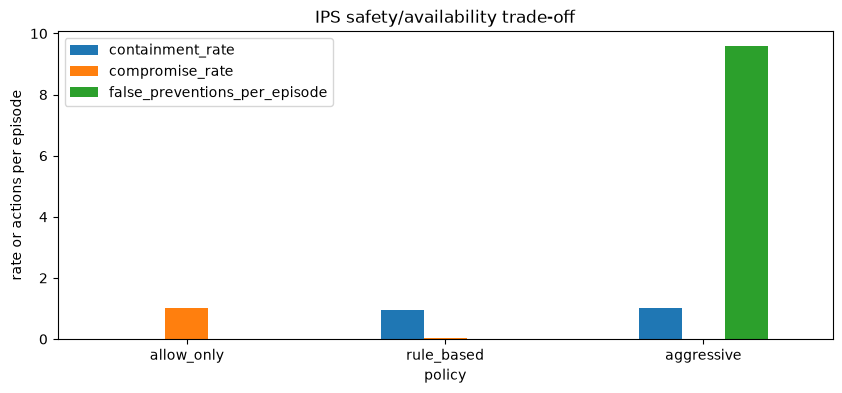

In [7]:
baseline_df = pd.DataFrame(report['ips_baselines']).set_index('policy')
display(baseline_df.style.format(precision=4))
baseline_df[['containment_rate', 'compromise_rate', 'false_preventions_per_episode']].plot.bar(figsize=(10,4), title='IPS safety/availability trade-off')
plt.ylabel('rate or actions per episode'); plt.xticks(rotation=0); plt.show()

## 7 — Train masked Double DQN

The online network selects the best valid next action and the target network evaluates it. Replay memory breaks temporal correlation; Huber loss limits sensitivity to large penalties; the target network updates periodically. Validation seeds never overlap training seeds. This is still simulator training.

In [8]:
from ips.dqn import DqnConfig
from ips.train_dqn import TrainConfig, train
dqn_config = DqnConfig(hidden_dim=64, batch_size=64, replay_capacity=10000, warmup_steps=128, target_update_steps=250, epsilon_decay_steps=5000)
train_config = TrainConfig(episodes=1000 if RUN_HEAVY else 100, validation_interval=100 if RUN_HEAVY else 25, validation_episodes=300 if RUN_HEAVY else 50)
trained = train(dqn_config, train_config, seed=SEED, output_dir=OUTPUT / 'simulator_dqn')
display(pd.DataFrame([trained.best_validation.to_dict()]))
print('Checkpoint:', trained.best_checkpoint, 'steps:', trained.total_steps, 'updates:', trained.updates)

,episodes,attack_episodes,benign_episodes,mean_return,return_std,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,masked_actions_per_episode,mean_steps
0,50,20,30,3.08,3.779365,1.0,0.0,0.0,0.62,0.0,30.64


Checkpoint: /Users/hexenmeister/Library/Mobile Documents/com~apple~CloudDocs/Desktop/don't delete update/codes/network-intrusion-detection-ml/results/notebook_ips_lab/simulator_dqn/dqn_best.pt steps: 2207 updates: 2080


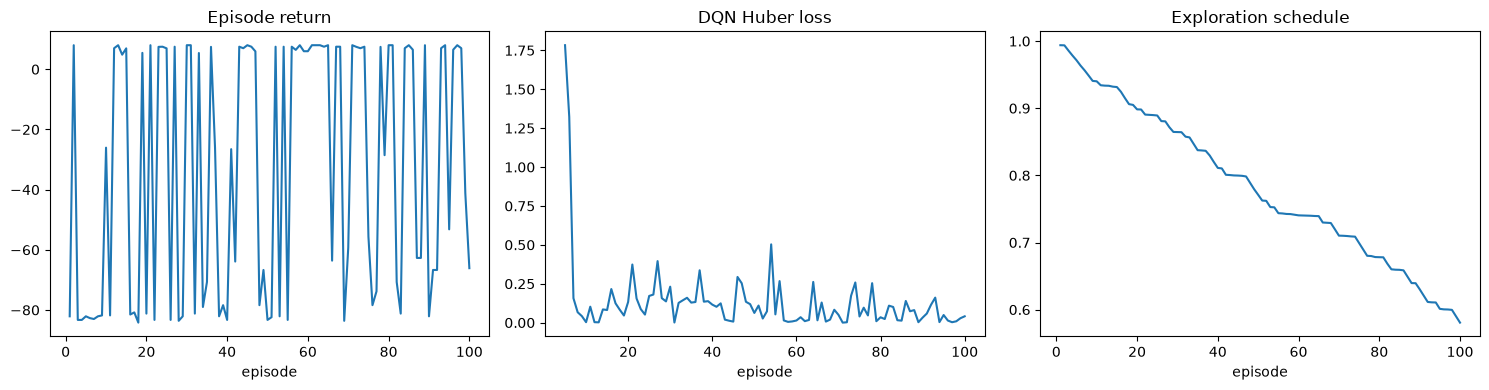

Interpretation: loss need not decrease monotonically in RL. Prevention metrics on disjoint scenarios decide the checkpoint.


In [9]:
history = pd.read_json(trained.history_path, lines=True)
fig, axes = plt.subplots(1, 3, figsize=(15,4))
history.plot(x='episode', y='episode_return', ax=axes[0], title='Episode return', legend=False)
history.dropna(subset=['mean_loss']).plot(x='episode', y='mean_loss', ax=axes[1], title='DQN Huber loss', legend=False)
history.plot(x='episode', y='epsilon', ax=axes[2], title='Exploration schedule', legend=False)
plt.tight_layout(); plt.show()
print('Interpretation: loss need not decrease monotonically in RL. Prevention metrics on disjoint scenarios decide the checkpoint.')

## 8 — Construct dataset-backed episodes

If `data/ips_events/events.parquet` exists, it is loaded. It must contain timestamps, campaign/group IDs, labels, criticality, attack stage, anomaly scores, and **out-of-fold detector probabilities**. Otherwise this cell creates an explicitly synthetic fixture to demonstrate the contract—it never labels that fixture as dataset evidence.

In [10]:
from ips.dataset import build_episodes, split_episodes_by_group, assert_group_disjoint
event_path = REPO / 'data' / 'ips_events' / 'events.parquet'
if event_path.exists():
    events = pd.read_parquet(event_path); evidence_kind = 'REAL DATASET-BACKED OBSERVATIONS'
else:
    rng = np.random.default_rng(SEED); rows=[]
    for group in range(30 if RUN_HEAVY else 12):
        attack = group % 2 == 0
        for step in range(6):
            rows.append({'episode_id': f'ep-{group}', 'group_id': f'campaign-{group}', 'timestamp': float(step), 'threat_probability': float(np.clip(rng.normal(0.72 if attack else 0.15, .1),0,1)), 'anomaly_score': float(np.clip(rng.normal(0.75 if attack else 0.2,.1),0,1)), 'attack_present': attack, 'attack_stage': (step+1)/6 if attack else 0.0, 'critical_service': group%5==0, 'attack_family': 'R2L' if attack else 'normal'})
    events = pd.DataFrame(rows); evidence_kind = 'SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE'
episodes = build_episodes(events)
splits = split_episodes_by_group(episodes, seed=SEED)
assert_group_disjoint(splits)
print(evidence_kind)
display(events.head())
display(pd.DataFrame([{'split': name, 'episodes': len(value), 'groups': len({e.group_id for e in value}), 'attack_episodes': sum(e.contains_attack for e in value)} for name, value in [('train', splits.train), ('validation', splits.validation), ('final_test', splits.test)]]))

SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE


,episode_id,group_id,timestamp,threat_probability,anomaly_score,attack_present,attack_stage,critical_service,attack_family
0,ep-0,campaign-0,0.0,0.750472,0.646002,True,0.166667,True,R2L
1,ep-0,campaign-0,1.0,0.795045,0.844056,True,0.333333,True,R2L
2,ep-0,campaign-0,2.0,0.524896,0.619782,True,0.500000,True,R2L
3,ep-0,campaign-0,3.0,0.732784,0.718376,True,0.666667,True,R2L
4,ep-0,campaign-0,4.0,0.718320,0.664696,True,0.833333,True,R2L


,split,episodes,groups,attack_episodes
0,train,8,8,3
1,validation,2,2,2
2,final_test,2,2,1


## 9 — Multi-seed dataset-backed experiment

Each seed independently trains on training episodes. Validation chooses that seed's checkpoint. The final-test split is then evaluated once. Mean ± standard deviation is reported across seeds. Observations may be real; action outcomes remain counterfactual until cyber-range interventions replace them.

In [11]:
from ips.dataset_experiment import DatasetTrainConfig, run_multi_seed
seeds = (42,43,44,45,46) if RUN_HEAVY else (42,43,44)
dataset_dqn = DqnConfig(hidden_dim=32, batch_size=16, replay_capacity=2000, warmup_steps=32, target_update_steps=50, epsilon_decay_steps=1000)
dataset_training = DatasetTrainConfig(episodes=500 if RUN_HEAVY else 40, validation_interval=100 if RUN_HEAVY else 20)
per_seed = run_multi_seed(splits, seeds=seeds, dqn=dataset_dqn, training=dataset_training, output_dir=OUTPUT / 'dataset_multi_seed')
display(per_seed.style.format(precision=4))
summary = per_seed.drop(columns='seed').agg(['mean','std']).T
display(summary.style.format(precision=4))
print('Evidence label:', evidence_kind)

,seed,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,mean_return,return_std
0,42,2,1,1.0000,0.0000,0.0000,0.5000,4.0000,4.0000
1,43,2,1,1.0000,0.0000,0.0000,0.5000,4.0000,4.0000
2,44,2,1,1.0000,0.0000,0.0000,0.5000,4.0000,4.0000


,mean,std
episodes,2.0000,0.0000
attack_episodes,1.0000,0.0000
containment_rate,1.0000,0.0000
compromise_rate,0.0000,0.0000
false_preventions_per_episode,0.0000,0.0000
disruptive_actions_per_episode,0.5000,0.0000
mean_return,4.0000,0.0000
return_std,4.0000,0.0000


Evidence label: SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE


## 10 — Candidate model discovery: measured versus theoretical

The executed candidate set varies DQN capacity, horizon discount, learning rate, batch size, and target-update frequency because these directly affect discrete sequential control. Masked PPO, constrained PPO, and a contextual bandit are listed separately as theoretically justified but **not executed** in this notebook. Quantization and context length are not relevant here: this is a small FP32 control network, not a language model.

In [12]:
from ips.experiment_analysis import DEFAULT_CANDIDATES, THEORETICAL_CANDIDATES, parameter_count
executed_catalog = pd.DataFrame([{**c.__dict__, 'parameters': parameter_count(c), 'quantization': 'FP32', 'executed': True} for c in DEFAULT_CANDIDATES])
theory_catalog = pd.DataFrame(THEORETICAL_CANDIDATES)
display(executed_catalog.style.hide(axis='index'))
display(theory_catalog.style.hide(axis='index'))
print('Interpretation: DQN variants can run comfortably on CPU because even the largest tested network has only thousands of parameters. PPO remains a recommendation, not a benchmark result.')

name,hidden_dim,gamma,learning_rate,batch_size,target_update_steps,episodes,parameters,quantization,executed
DQN-small-fast,16,0.950000,0.001000,16,50,60,519,FP32,True
DQN-small-long-horizon,16,0.990000,0.001000,16,50,60,519,FP32,True
DQN-balanced,32,0.990000,0.001000,32,75,60,1543,FP32,True
DQN-low-lr,32,0.990000,0.000300,32,75,60,1543,FP32,True
DQN-large,64,0.990000,0.001000,32,100,60,5127,FP32,True
DQN-large-batch,64,0.990000,0.001000,64,100,60,5127,FP32,True


model,executed,why,strength,weakness,environment_fit
Masked PPO,False,stable policy-gradient comparison with the same discrete safety mask,less sensitive than DQN to Q-value scale and replay distribution,less sample-efficient; needs a vectorized environment,realistic after dataset episodes and reward sensitivity stabilize
Constrained PPO,False,separates prevention reward from explicit disruption constraints,directly models an availability/safety budget,more complex optimization and multiplier tuning,recommended final simulator/cyber-range policy
Contextual bandit,False,tests whether sequential credit assignment is genuinely necessary,"simple, fast, highly interpretable baseline",cannot value delayed containment or attack progression,strong additional baseline


Interpretation: DQN variants can run comfortably on CPU because even the largest tested network has only thousands of parameters. PPO remains a recommendation, not a benchmark result.


## 11 — Controlled multi-configuration benchmark

Every candidate uses the same campaign-disjoint split and final-test episodes. Runtime is wall-clock time, checkpoint memory is serialized model size, and peak memory is measured with Python `tracemalloc`—it does not include every native allocator, so it is a comparative development metric rather than total process RAM.

In [13]:
from ips.experiment_analysis import benchmark_candidates, add_objective_scores
candidates = tuple(type(c)(**{**c.__dict__, 'episodes': 150 if RUN_HEAVY else 50}) for c in DEFAULT_CANDIDATES)
bench = benchmark_candidates(splits, candidates=candidates, seed=SEED, output_dir=OUTPUT / 'candidate_benchmark')
bench = add_objective_scores(bench)
comparison_cols = ['name','parameters','quantization','checkpoint_mb','peak_python_memory_mb','runtime_s','throughput_steps_s','containment_rate','compromise_rate','false_preventions_per_episode','safety_quality','pareto_optimal']
display(bench[comparison_cols].sort_values('safety_quality', ascending=False).style.format(precision=4).hide(axis='index'))
print('Result:', bench.loc[bench.safety_quality.idxmax(), 'name'], 'has the highest observed safety quality.')
print('Next implication: inspect whether that gain survives runtime/memory trade-offs and parameter sensitivity before selecting it.')

name,parameters,quantization,checkpoint_mb,peak_python_memory_mb,runtime_s,throughput_steps_s,containment_rate,compromise_rate,false_preventions_per_episode,safety_quality,pareto_optimal
DQN-small-fast,519,FP32,0.0052,0.3761,0.1309,1665.6845,1.0000,0.0000,0.0000,1.0000,True
DQN-small-long-horizon,519,FP32,0.0052,0.3384,0.1538,1417.3642,1.0000,0.0000,0.0000,1.0000,False
DQN-balanced,1543,FP32,0.0091,0.3387,0.1407,1549.8640,1.0000,0.0000,0.0000,1.0000,False
DQN-low-lr,1543,FP32,0.0091,0.3374,0.1334,1634.1947,1.0000,0.0000,0.0000,1.0000,False
DQN-large,5127,FP32,0.0228,0.3326,0.1292,1687.3903,1.0000,0.0000,0.0000,1.0000,False
DQN-large-batch,5127,FP32,0.0228,0.3342,0.0914,2384.1628,1.0000,0.0000,0.0000,1.0000,True


Result: DQN-small-fast has the highest observed safety quality.
Next implication: inspect whether that gain survives runtime/memory trade-offs and parameter sensitivity before selecting it.


## 12 — Visual model comparison and Pareto frontier

A model is Pareto-optimal when no other measured configuration is at least as good in quality, runtime, and checkpoint size while being strictly better in one. Dominated candidates are usually poor follow-up choices unless they contribute stability or an unmeasured operational property.

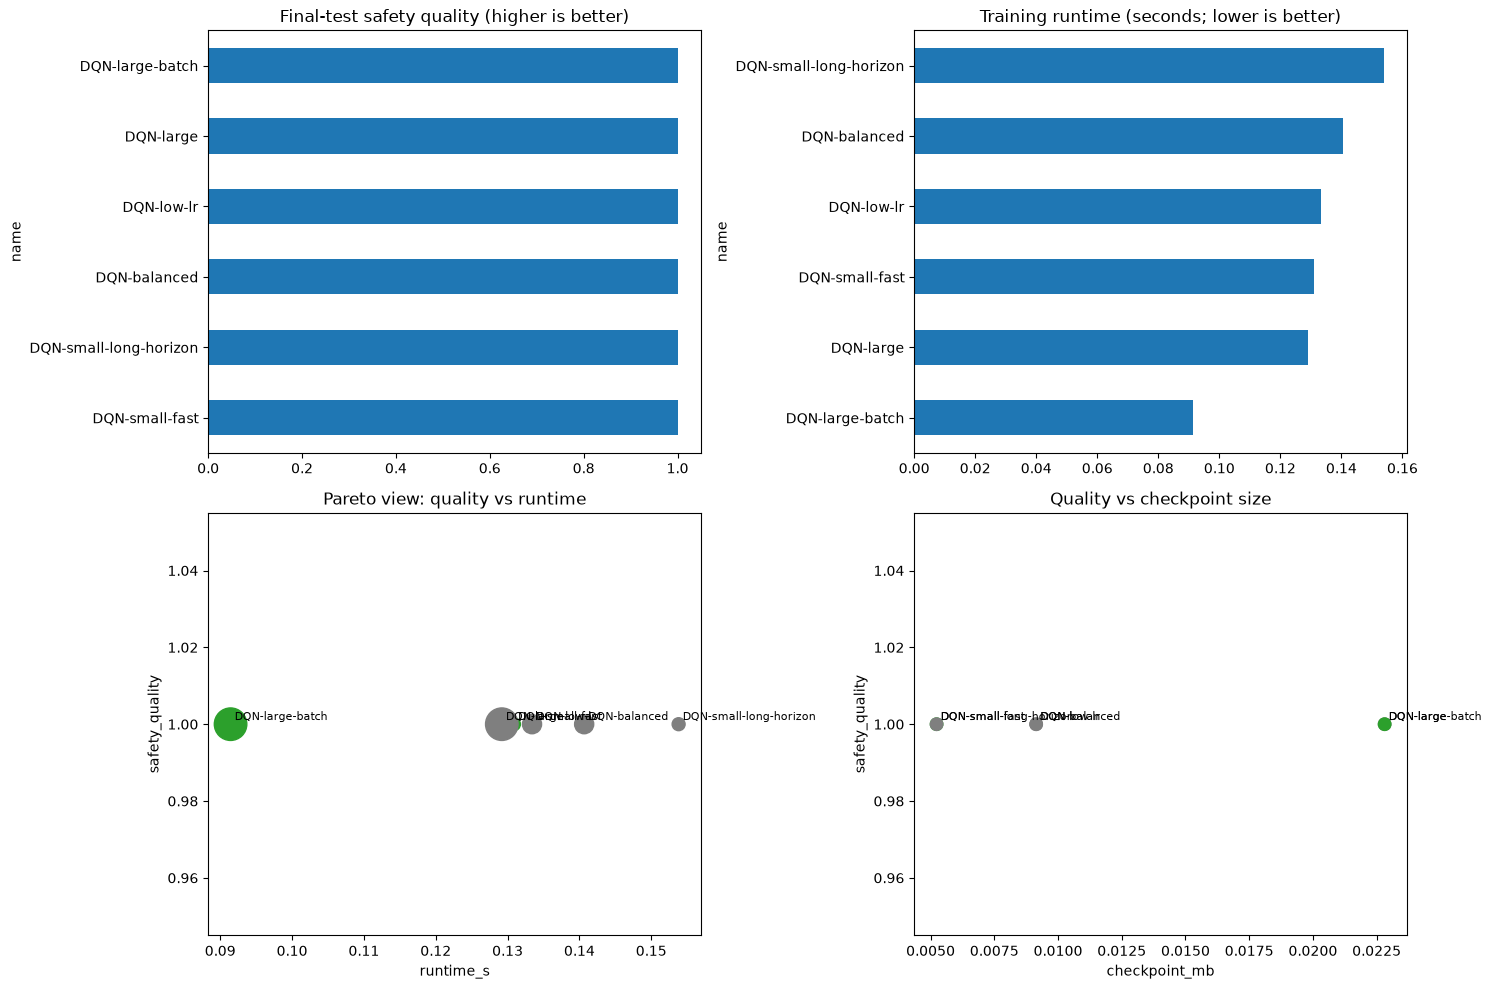

Pareto candidates: DQN-small-fast, DQN-large-batch


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
bench.sort_values('safety_quality').plot.barh(x='name', y='safety_quality', ax=axes[0,0], legend=False, title='Final-test safety quality (higher is better)')
bench.sort_values('runtime_s').plot.barh(x='name', y='runtime_s', ax=axes[0,1], legend=False, title='Training runtime (seconds; lower is better)')
bench.plot.scatter(x='runtime_s', y='safety_quality', s=bench.parameters/10+35, c=bench.pareto_optimal.map({True:'tab:green',False:'tab:gray'}), ax=axes[1,0], title='Pareto view: quality vs runtime')
bench.plot.scatter(x='checkpoint_mb', y='safety_quality', s=80, c=bench.pareto_optimal.map({True:'tab:green',False:'tab:gray'}), ax=axes[1,1], title='Quality vs checkpoint size')
for ax in (axes[1,0], axes[1,1]):
    for _, r in bench.iterrows(): ax.annotate(r['name'], (r[ax.get_xlabel()], r['safety_quality']), fontsize=8, xytext=(3,3), textcoords='offset points')
plt.tight_layout(); plt.show()
print('Pareto candidates:', ', '.join(bench.loc[bench.pareto_optimal, 'name']))

## 13 — Parameter impact and sensitivity

Spearman correlation measures monotonic association and is appropriate for this small, non-Gaussian grid. It does not establish causality, especially because parameters were not varied in a full factorial design. Sensitivity plots reveal whether larger capacity or batch size improves quality consistently or only in certain regions.

parameter,rho_safety_quality,rho_runtime_s,rho_checkpoint_mb,rho_throughput_steps_s,importance
hidden_dim,nan,-0.717,1.000,0.717,1.000
target_update_steps,nan,-0.717,1.000,0.717,1.000
batch_size,nan,-0.617,0.904,0.617,0.904
gamma,nan,0.131,0.548,-0.131,0.548
learning_rate,nan,-0.131,0.000,0.131,0.131


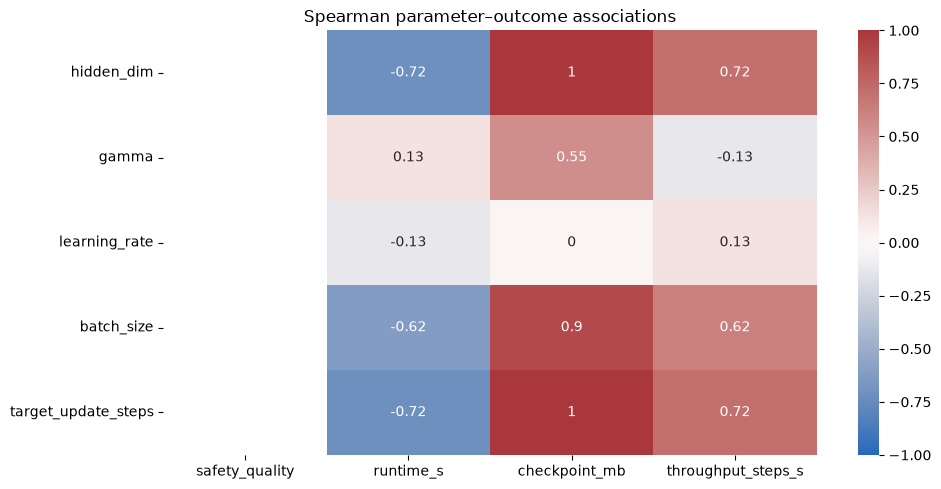

Most influential measured parameter: hidden_dim (max |rho|=1.00). Treat as association, not causal importance.


In [15]:
import seaborn as sns
from ips.experiment_analysis import parameter_effects
effects = parameter_effects(bench)
display(effects.style.format(precision=3).hide(axis='index'))
params = ['hidden_dim','gamma','learning_rate','batch_size','target_update_steps']
outs = ['safety_quality','runtime_s','checkpoint_mb','throughput_steps_s']
corr = bench[params+outs].corr(method='spearman').loc[params, outs]
plt.figure(figsize=(10,5)); sns.heatmap(corr, annot=True, center=0, cmap='vlag', vmin=-1, vmax=1)
plt.title('Spearman parameter–outcome associations'); plt.tight_layout(); plt.show()
top_effect = effects.iloc[0]
print(f"Most influential measured parameter: {top_effect.parameter} (max |rho|={top_effect.importance:.2f}). Treat as association, not causal importance.")

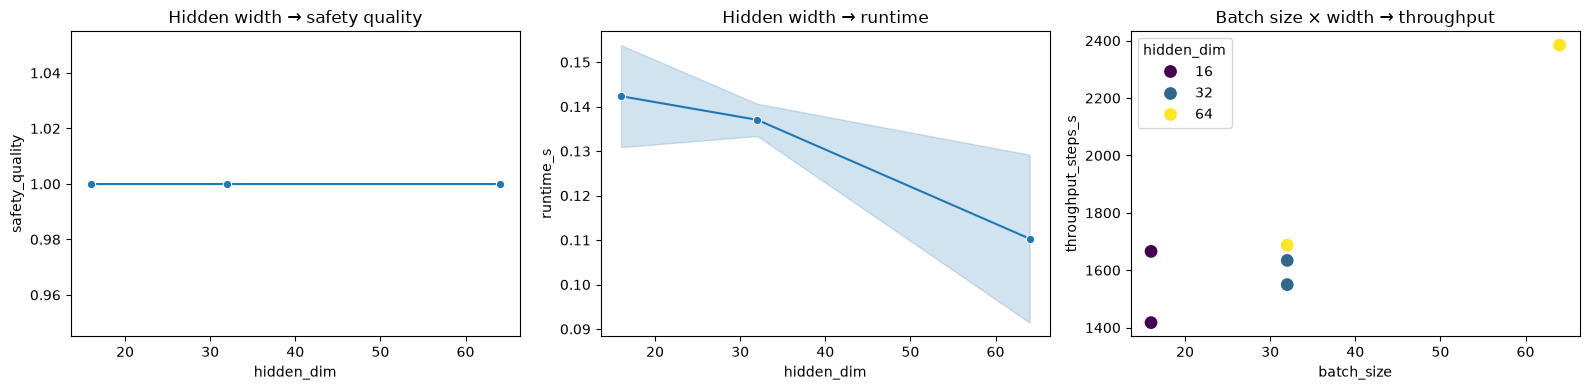

Expected: width generally increases parameter/checkpoint cost. Observed quality may be non-monotonic because additional capacity does not guarantee better policy learning.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.lineplot(data=bench, x='hidden_dim', y='safety_quality', marker='o', ax=axes[0]); axes[0].set_title('Hidden width → safety quality')
sns.lineplot(data=bench, x='hidden_dim', y='runtime_s', marker='o', ax=axes[1]); axes[1].set_title('Hidden width → runtime')
sns.scatterplot(data=bench, x='batch_size', y='throughput_steps_s', hue='hidden_dim', palette='viridis', s=100, ax=axes[2]); axes[2].set_title('Batch size × width → throughput')
plt.tight_layout(); plt.show()
print('Expected: width generally increases parameter/checkpoint cost. Observed quality may be non-monotonic because additional capacity does not guarantee better policy learning.')

## 14 — Parameter interactions

The grid supports a bounded width × batch-size interaction view. Blank combinations were not executed and must not be interpolated as measured evidence. A surprising reversal—where a larger batch helps one width but hurts another—is a reason to run a factorial follow-up.

batch_size,16,32,64
hidden_dim,,,
16,1.000,nan,nan
32,nan,1.000,nan
64,nan,1.000,1.000


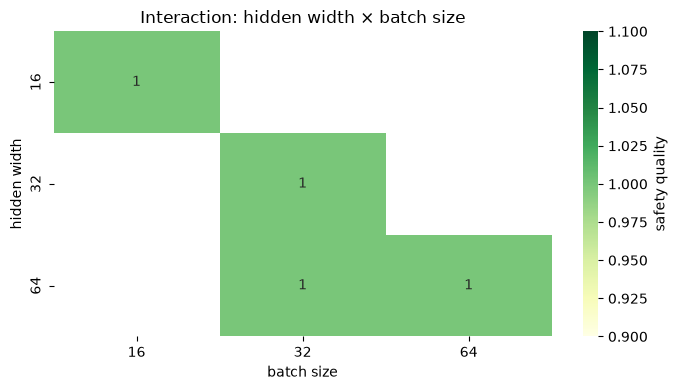

Observed 4/9 interaction cells. Next step should fill missing cells before strong interaction claims.


In [17]:
from ips.experiment_analysis import interaction_table
interaction = interaction_table(bench)
display(interaction.style.background_gradient(cmap='YlGn').format(precision=3))
plt.figure(figsize=(7,4)); sns.heatmap(interaction, annot=True, cmap='YlGn', cbar_kws={'label':'safety quality'})
plt.title('Interaction: hidden width × batch size'); plt.ylabel('hidden width'); plt.xlabel('batch size'); plt.tight_layout(); plt.show()
observed_cells = int(interaction.notna().sum().sum())
print(f'Observed {observed_cells}/{interaction.size} interaction cells. Next step should fill missing cells before strong interaction claims.')

## 15 — Automatic outlier detection and root-cause association

Robust median absolute deviation (MAD) is used because benchmark grids are small and runtime distributions can be skewed. Runs are never deleted automatically. For each flagged run, the notebook names the anomalous outcome and the most unusual tested parameter, explicitly labelling this as association rather than causation.

name,outlier_score,runtime_s,peak_python_memory_mb,safety_quality,outlier_explanation
DQN-small-fast,11.518,0.131,0.376,1.000,peak_python_memory_mb is robustly above median; gamma is the most unusual tested parameter. Association only—this grid does not prove causality.
DQN-large-batch,4.789,0.091,0.334,1.000,runtime_s is robustly below median; batch_size is the most unusual tested parameter. Association only—this grid does not prove causality.


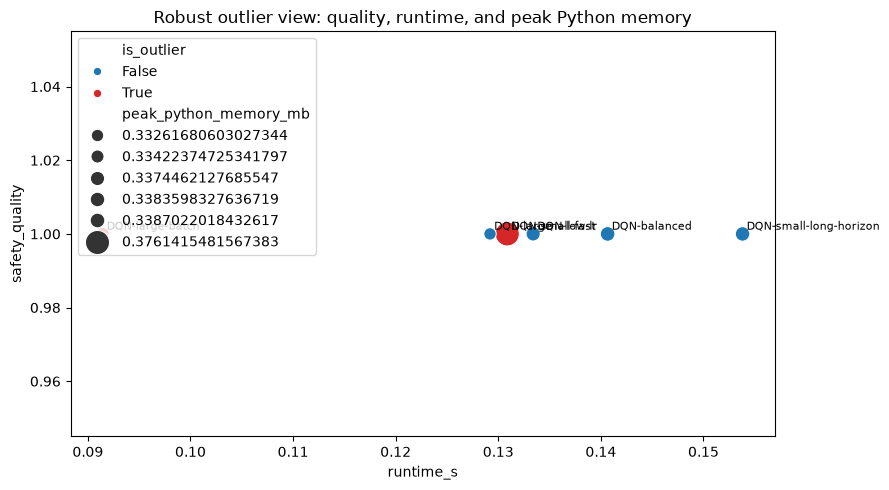

Detected outliers: 2 — retain and investigate them; do not silently remove them.


In [18]:
from ips.experiment_analysis import detect_outliers
diagnosed = detect_outliers(bench)
outliers = diagnosed[diagnosed.is_outlier]
display(outliers[['name','outlier_score','runtime_s','peak_python_memory_mb','safety_quality','outlier_explanation']].style.format(precision=3).hide(axis='index'))
plt.figure(figsize=(9,5)); sns.scatterplot(data=diagnosed, x='runtime_s', y='safety_quality', hue='is_outlier', size='peak_python_memory_mb', sizes=(80,300), palette={False:'tab:blue',True:'tab:red'})
for _, r in diagnosed.iterrows(): plt.annotate(r['name'], (r.runtime_s,r.safety_quality), fontsize=8, xytext=(3,3), textcoords='offset points')
plt.title('Robust outlier view: quality, runtime, and peak Python memory'); plt.tight_layout(); plt.show()
print('Detected outliers:', len(outliers), '— retain and investigate them; do not silently remove them.')

## 16 — Statistical reliability

The earlier dataset-backed DQN run supplies repeated final-test measurements. Mean, median, standard deviation, range, coefficient of variation, and a normal-approximation 95% confidence interval are shown. With only three quick-mode seeds, intervals are descriptive; heavy mode's five seeds is the minimum project standard.

,mean,median,std,min,max,cv,ci95_halfwidth
episodes,2.0000,2.0000,0.0000,2.0000,2.0000,0.0000,0.0000
attack_episodes,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000
containment_rate,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000
compromise_rate,0.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
false_preventions_per_episode,0.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
disruptive_actions_per_episode,0.5000,0.5000,0.0000,0.5000,0.5000,0.0000,0.0000
mean_return,4.0000,4.0000,0.0000,4.0000,4.0000,0.0000,0.0000
return_std,4.0000,4.0000,0.0000,4.0000,4.0000,0.0000,0.0000


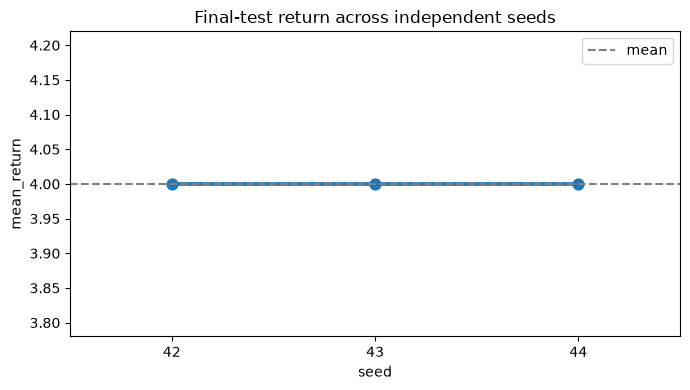

If confidence intervals overlap materially between finalists, report a tie and collect more seeds rather than naming a winner.


In [19]:
numeric = per_seed.select_dtypes('number').drop(columns='seed')
reliability = pd.DataFrame({'mean':numeric.mean(), 'median':numeric.median(), 'std':numeric.std(ddof=1), 'min':numeric.min(), 'max':numeric.max()})
reliability['cv'] = reliability['std'] / reliability['mean'].abs().replace(0,np.nan)
reliability['ci95_halfwidth'] = 1.96 * reliability['std'] / np.sqrt(len(per_seed))
display(reliability.style.format(precision=4))
metric='mean_return'; plt.figure(figsize=(7,4)); sns.pointplot(data=per_seed, x='seed', y=metric, errorbar=None); plt.axhline(per_seed[metric].mean(), ls='--', color='gray', label='mean'); plt.title('Final-test return across independent seeds'); plt.legend(); plt.tight_layout(); plt.show()
print('If confidence intervals overlap materially between finalists, report a tie and collect more seeds rather than naming a winner.')

## 17 — Optimal configurations and dynamic recommendations

There is no universal best model. Quality, speed, memory, and overall winners are calculated independently. The overall score is transparent: 60% normalized safety quality, 25% speed, and 15% checkpoint memory. Change these weights if deployment priorities differ.

In [20]:
from ips.experiment_analysis import objective_winners, dynamic_recommendations
winners = objective_winners(bench)
display(winners[['objective','name','safety_quality','runtime_s','checkpoint_mb','overall_score','pareto_optimal']].style.format(precision=4).hide(axis='index'))
recommendations = dynamic_recommendations(bench)
for message in recommendations: print('•', message)

objective,name,safety_quality,runtime_s,checkpoint_mb,overall_score,pareto_optimal
best_quality,DQN-small-fast,1.0000,0.1309,0.0052,0.8419,True
fastest,DQN-large-batch,1.0000,0.0914,0.0228,0.8500,True
lowest_checkpoint_memory,DQN-small-fast,1.0000,0.1309,0.0052,0.8419,True
best_overall_60Q_25S_15M,DQN-large-batch,1.0000,0.0914,0.0228,0.8500,True


• Best observed overall trade-off: DQN-large-batch (score=0.850).
• Quality priority: DQN-small-fast with safety_quality=1.000.
• Speed priority: DQN-large-batch at 0.091s.
• Strongest measured monotonic association: hidden_dim (max |Spearman rho|=1.00).
• Pareto candidates: DQN-small-fast, DQN-large-batch.
• Next experiment: add an intermediate/extended hidden-width point to resolve the quality-cost curve.
• Reliability gap: repeat Pareto finalists across at least five seeds before declaring a winner.
• Model-family gap: benchmark a contextual bandit and masked PPO only after the DQN reward-sensitivity check.


## 18 — Dynamic experiment dashboard

This compact dashboard is generated entirely from the current run. Rerunning with different candidates, data, or seeds updates every winner, outlier count, influential parameter, Pareto set, and next recommendation.

In [21]:
best_quality = winners.set_index('objective').loc['best_quality']
fastest = winners.set_index('objective').loc['fastest']
lowest_memory = winners.set_index('objective').loc['lowest_checkpoint_memory']
best_overall = winners.set_index('objective').loc['best_overall_60Q_25S_15M']
dashboard = pd.Series({'experiments_executed':len(bench), 'models_compared':bench.name.nunique(), 'configurations_tested':len(bench), 'best_quality':f"{best_quality['name']} ({best_quality['safety_quality']:.3f})", 'fastest':f"{fastest['name']} ({fastest['runtime_s']:.3f}s)", 'lowest_memory':f"{lowest_memory['name']} ({lowest_memory['checkpoint_mb']:.3f} MB)", 'best_overall':best_overall['name'], 'detected_outliers':len(outliers), 'most_influential_parameter':effects.iloc[0].parameter, 'interaction_coverage':f'{observed_cells}/{interaction.size}', 'pareto_candidates':', '.join(bench.loc[bench.pareto_optimal,'name']), 'recommended_next_experiment':recommendations[-1]}, name='Current dynamic result')
display(dashboard.to_frame())
dashboard.to_json(OUTPUT / 'experiment_dashboard.json', indent=2)

,Current dynamic result
experiments_executed,6
models_compared,6
configurations_tested,6
best_quality,DQN-small-fast (1.000)
fastest,DQN-large-batch (0.091s)
lowest_memory,DQN-small-fast (0.005 MB)
best_overall,DQN-large-batch
detected_outliers,2
most_influential_parameter,hidden_dim
interaction_coverage,4/9


## 19 — Final interpretation and next evidence gate

A strong result requires all of the following: group-disjoint episodes, out-of-fold detector scores, at least three RL seeds, validation-only checkpoint selection, one final-test evaluation per seed, and comparison against allow/rule/aggressive policies. If this notebook used the synthetic fixture, it proves software correctness only. The next evidence gate is creating `data/ips_events/events.parquet` from a timestamped dataset, followed by contained cyber-range intervention logs that can replace counterfactual outcomes.

In [22]:
final = {'evidence_kind': evidence_kind, 'tests_passed': tests.returncode == 0, 'simulator_dqn': trained.best_validation.to_dict(), 'dataset_multi_seed_mean': per_seed.drop(columns='seed').mean(numeric_only=True).to_dict(), 'dataset_multi_seed_std': per_seed.drop(columns='seed').std(ddof=0, numeric_only=True).to_dict()}
(OUTPUT / 'notebook_summary.json').write_text(json.dumps(final, indent=2, sort_keys=True)+'\n', encoding='utf-8')
display(pd.Series(final, name='current project conclusion'))
print('Saved:', OUTPUT / 'notebook_summary.json')

evidence_kind              SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE
tests_passed                                                            True
simulator_dqn              {'episodes': 50, 'attack_episodes': 20, 'benig...
dataset_multi_seed_mean    {'episodes': 2.0, 'attack_episodes': 1.0, 'con...
dataset_multi_seed_std     {'episodes': 0.0, 'attack_episodes': 0.0, 'con...
Name: current project conclusion, dtype: object

Saved: /Users/hexenmeister/Library/Mobile Documents/com~apple~CloudDocs/Desktop/don't delete update/codes/network-intrusion-detection-ml/results/notebook_ips_lab/notebook_summary.json
